# 7. Кластеризація на основі найближчих сусідів (KNN)

Будуємо граф зв'язності через NearestNeighbors, потім агломеративна кластеризація на графі.

Точки зі спільними найближчими сусідами потрапляють в один кластер — враховує локальну структуру.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json, time
from sklearn.neighbors import kneighbors_graph
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

df = pd.read_csv('data_processed.csv')
with open('top4_pairs.json') as f:
    pairs = json.load(f)

np.random.seed(42)
idx_s = np.random.choice(len(df), min(5000, len(df)), replace=False)
df_s = df.iloc[idx_s].reset_index(drop=True)
print(f"Вибірка: {df_s.shape}")
N = len(pairs)

Вибірка: (5000, 5)


## 7.1 Підбір k

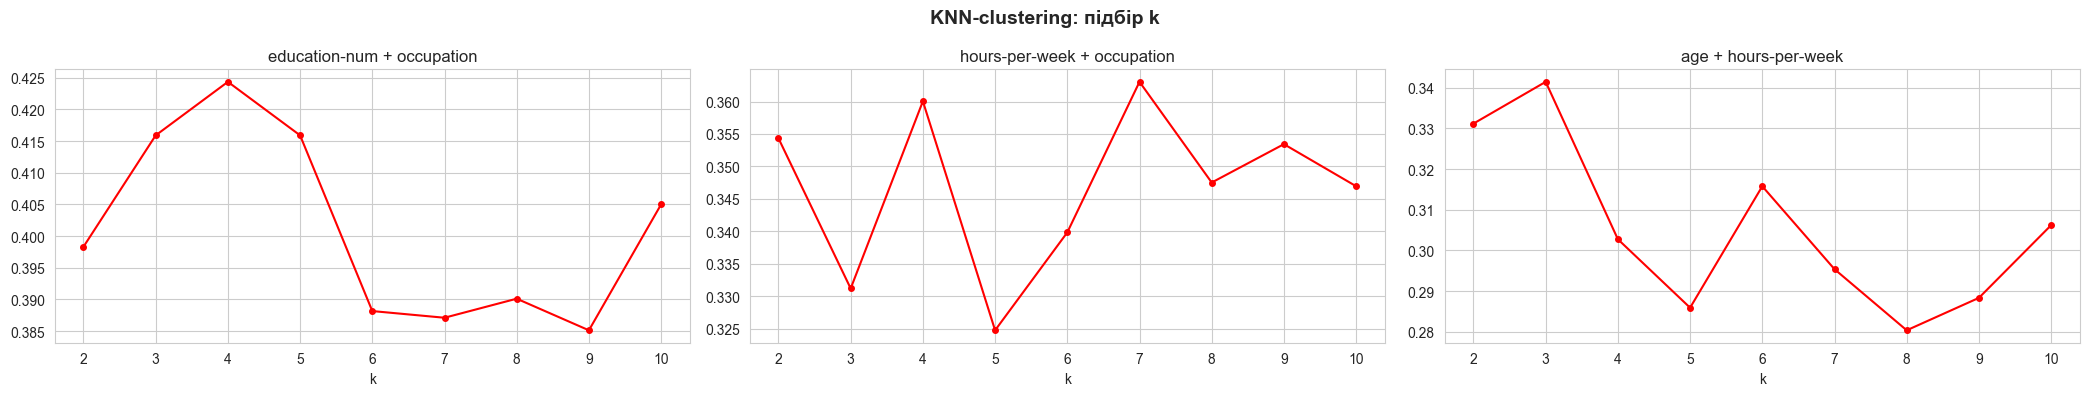

education-num + occupation: k = 4
hours-per-week + occupation: k = 7
age + hours-per-week: k = 3


In [2]:
K_range = range(2, 11)
best_k = {}
fig, axes = plt.subplots(1, N, figsize=(7*N, 4))

for j, pair in enumerate(pairs):
    X = StandardScaler().fit_transform(df_s[pair].values)
    conn = kneighbors_graph(X, n_neighbors=10, include_self=False)
    sils = [silhouette_score(X, AgglomerativeClustering(n_clusters=k, connectivity=conn, linkage='ward').fit_predict(X)) for k in K_range]
    axes[j].plot(list(K_range), sils, 'ro-', markersize=4)
    axes[j].set_title(f'{pair[0]} + {pair[1]}'); axes[j].set_xlabel('k')
    best_k[j] = list(K_range)[np.argmax(sils)]

plt.suptitle('KNN-clustering: підбір k', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
for j, p in enumerate(pairs): print(f"{p[0]} + {p[1]}: k = {best_k[j]}")

## 7.2 Кластеризація та 2D-візуалізація

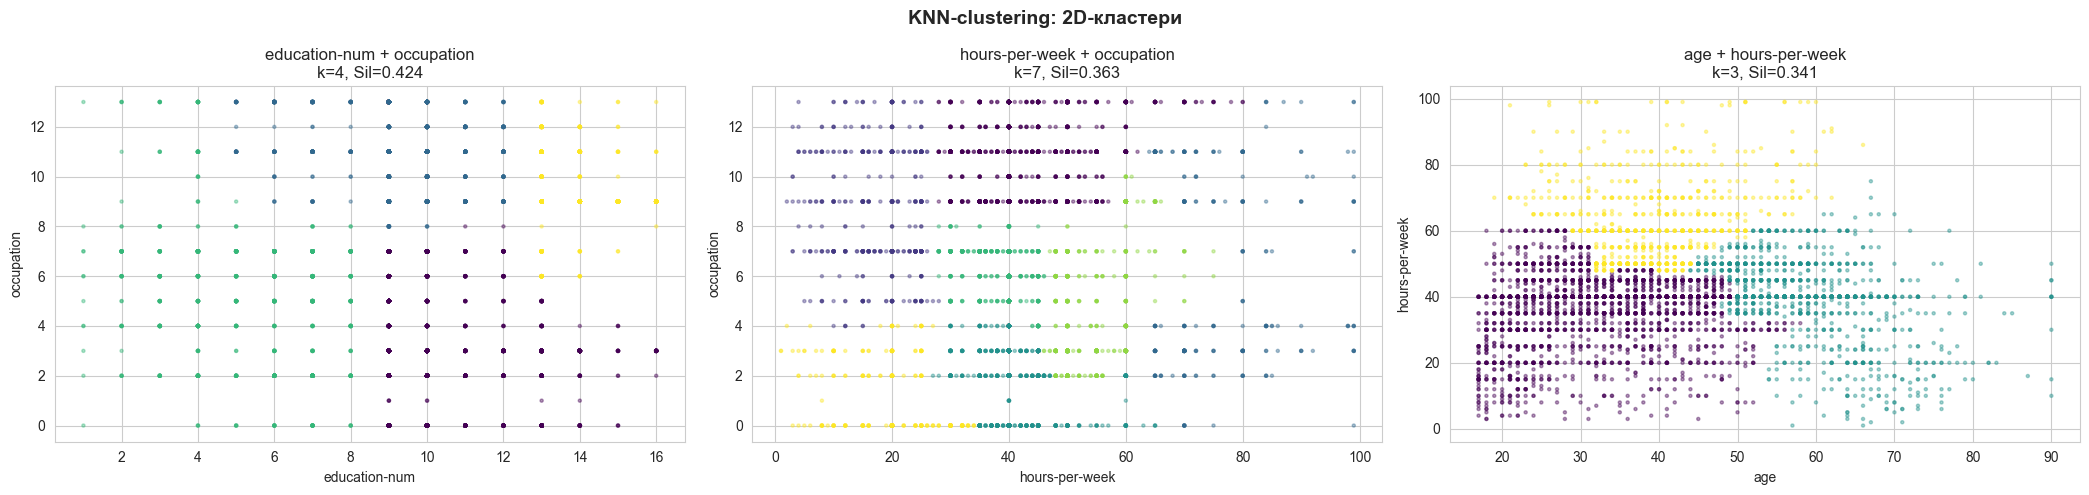

,algorithm,pair,k,silhouette,davies_bouldin,calinski_harabasz,time
0,KNN-clustering,education-num + occupation,4,0.424358,0.747209,4050.630579,5.145138
1,KNN-clustering,hours-per-week + occupation,7,0.363037,0.868116,3097.984710,1.959720
2,KNN-clustering,age + hours-per-week,3,0.341444,0.911668,2630.177745,0.813391


In [3]:
all_results = []
fig, axes = plt.subplots(1, N, figsize=(7*N, 5))

for j, pair in enumerate(pairs):
    X_raw = df_s[pair].values
    X = StandardScaler().fit_transform(X_raw)
    conn = kneighbors_graph(X, n_neighbors=10, include_self=False)
    k = best_k[j]
    
    start = time.time()
    labels = AgglomerativeClustering(n_clusters=k, connectivity=conn, linkage='ward').fit_predict(X)
    elapsed = time.time() - start
    
    sil = silhouette_score(X, labels)
    db = davies_bouldin_score(X, labels)
    ch = calinski_harabasz_score(X, labels)
    
    all_results.append({'algorithm': 'KNN-clustering', 'pair': f'{pair[0]} + {pair[1]}',
                        'k': int(k), 'silhouette': sil, 'davies_bouldin': db,
                        'calinski_harabasz': ch, 'time': elapsed})
    
    idx = np.random.RandomState(42).choice(len(X_raw), min(5000, len(X_raw)), replace=False)
    axes[j].scatter(X_raw[idx, 0], X_raw[idx, 1], c=labels[idx], cmap='viridis', alpha=0.4, s=5)
    axes[j].set_xlabel(pair[0]); axes[j].set_ylabel(pair[1])
    axes[j].set_title(f'{pair[0]} + {pair[1]}\nk={k}, Sil={sil:.3f}')

plt.suptitle('KNN-clustering: 2D-кластери', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

results_df = pd.DataFrame(all_results)
results_df.to_csv('results_knn.csv', index=False)
results_df